# 📊 American Express - Default Prediction 

**Group:**
**Course:** SC4000 Machine Learning &nbsp;•&nbsp; **Platform:** Kaggle   
**Goal:** Predict customer default using a fast, memory-safe pipeline and GPU-accelerated machine learning models.


### Importing Libraries

We use NumPy/Pandas for data, a two-pass memory-safe feature builder, and GPU-accelerated
LightGBM for modeling. The AMEX competition metric is implemented as a custom callback.


In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, (CSV file I/O)
import os, gc
import warnings
warnings.filterwarnings("ignore")
import tensorflow as tf
import tensorflow.keras.backend as K
print('Using TensorFlow version',tf.__version__)
import cupy as cp
import cudf
from cuml.ensemble import RandomForestClassifier as cuRF
from sklearn.ensemble import RandomForestClassifier as skRF
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import math, sys
import random
import matplotlib.pyplot as plt
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


2025-11-14 12:25:38.506583: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763123138.746395      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763123138.806838      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Using TensorFlow version 2.18.0
/kaggle/input/amex-default-prediction/sample_submission.csv
/kaggle/input/amex-default-prediction/train_data.csv
/kaggle/input/amex-default-prediction/test_data.csv
/kaggle/input/amex-default-prediction/train_labels.csv


### Loading Dataset

In [2]:
csv_path = '/kaggle/input/amex-default-prediction/train_labels.csv'
df = pd.read_csv(csv_path)
print(df.head())

                                         customer_ID  target
0  0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...       0
1  00000fd6641609c6ece5454664794f0340ad84dddce9a2...       0
2  00001b22f846c82c51f6e3958ccd81970162bae8b007e8...       0
3  000041bdba6ecadd89a52d11886e8eaaec9325906c9723...       0
4  00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8a...       0


In [3]:
os.environ["CUDA_VISIBLE_DEVICES"]="0"

# TENSORFLOW : 8GB RAM
# RAPIDS: 7GB RAM
LIMIT = 8
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
  try:
    tf.config.experimental.set_virtual_device_configuration(
        gpus[0],
        [tf.config.experimental.VirtualDeviceConfiguration(memory_limit=1024*LIMIT)])
    logical_gpus = tf.config.experimental.list_logical_devices('GPU')
  except RuntimeError as e:
    print(e)
print('Restrict TensorFlow to max %iGB GPU RAM'%LIMIT)
print('RAPIDS to use %iGB GPU RAM'%(15-LIMIT))

Restrict TensorFlow to max 8GB GPU RAM
RAPIDS to use 7GB GPU RAM


I0000 00:00:1763123163.284863      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 8192 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1763123163.285638      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [4]:
PATH_TO_CUSTOMER_HASHES = None
PROCESS_DATA = True
PATH_TO_DATA = '/kaggle/working/data/'
TRAIN_MODEL = True
PATH_TO_MODEL = '/kaggle/working/model/'
INFER_TEST = True

## Exploratory Data Analysis

In [5]:
# read only the header to get column names
cols = pd.read_csv('/kaggle/input/amex-default-prediction/train_data.csv', nrows=0).columns
print(f"{len(cols)} columns detected")

# just peek at dtypes from first few rows (cheap)
sample = pd.read_csv('/kaggle/input/amex-default-prediction/train_data.csv', nrows=1000)
print(sample.dtypes)

# count total rows (fast line count)
import subprocess, shlex
n = int(subprocess.check_output(shlex.split("wc -l /kaggle/input/amex-default-prediction/train_data.csv")).split()[0]) - 1
print(f"Total rows: {n:,}")
summary = sample.dtypes.value_counts()
print(summary)

190 columns detected
customer_ID     object
S_2             object
P_2            float64
D_39           float64
B_1            float64
                ...   
D_141          float64
D_142          float64
D_143          float64
D_144          float64
D_145          float64
Length: 190, dtype: object
Total rows: 5,531,451
float64    185
object       4
int64        1
Name: count, dtype: int64


In [6]:
np.random.seed(42); random.seed(42)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

DATA_DIR = "/kaggle/input/amex-default-prediction"
WORK_DIR = "/kaggle/working"

# knobs for chunked scans (tune based on RAM)
EDA_CHUNKSIZE = 2_000_000
EDA_SAMPLE_ROWS = 1_000_000  # for quick sample-based EDA (set None to scan full)

In [7]:
for fname in ["train_data.csv", "test_data.csv", "train_labels.csv", "sample_submission.csv"]:
    fpath = os.path.join(DATA_DIR, fname)
    size_gb = os.path.getsize(fpath) / (1024**3)
    print(f"{fname:22s}  {size_gb:6.2f} GB")

train_data.csv           15.27 GB
test_data.csv            31.50 GB
train_labels.csv          0.03 GB
sample_submission.csv     0.06 GB


In [8]:
labels = pd.read_csv(f"{DATA_DIR}/train_labels.csv")
pos_rate = labels["target"].mean()
print(f"Train customers: {len(labels):,}")
print(f"Positive rate (target=1): {pos_rate:.4f}")
display(labels["target"].value_counts().rename_axis("target").to_frame("count"))

Train customers: 458,913
Positive rate (target=1): 0.2589


,count
target,
0,340085
1,118828


[EDA-3] chunks processed: 2
Customers seen: 458,913
Statements per customer — min/median/mean/max: 1 / 13.0 / 12.05 / 13
Date range (S_2): 2017-03-01 → 2018-03-31


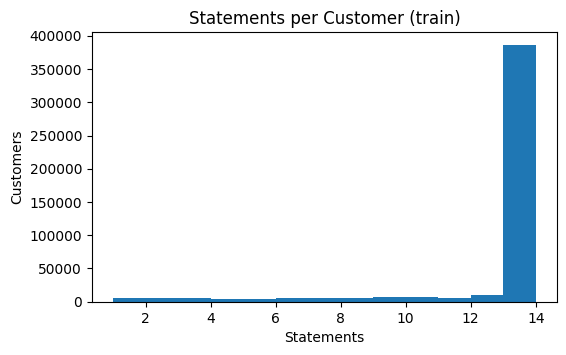

In [9]:
# EDA-3 — Per-customer statement counts + date range (chunked)
cust_counts = {}
min_date, max_date = None, None

reader = pd.read_csv(f"{DATA_DIR}/train_data.csv", usecols=["customer_ID", "S_2"], chunksize=EDA_CHUNKSIZE)
for i, chunk in enumerate(reader, 1):
    # track date range
    chunk["S_2"] = pd.to_datetime(chunk["S_2"])
    cmin, cmax = chunk["S_2"].min(), chunk["S_2"].max()
    min_date = cmin if min_date is None or cmin < min_date else min_date
    max_date = cmax if max_date is None or cmax > max_date else max_date

    # counts within chunk
    cnt = chunk["customer_ID"].value_counts()
    for cid, n in cnt.items():
        cust_counts[cid] = cust_counts.get(cid, 0) + int(n)

    if i % 2 == 0:
        print(f"[EDA-3] chunks processed: {i}")
    del chunk, cnt
    gc.collect()

counts = np.array(list(cust_counts.values()))
print(f"Customers seen: {len(counts):,}")
print(f"Statements per customer — min/median/mean/max: {counts.min()} / {np.median(counts):.1f} / {counts.mean():.2f} / {counts.max()}")
print(f"Date range (S_2): {min_date.date()} → {max_date.date()}")

# histogram of statement counts
plt.figure(figsize=(6,3.5))
plt.hist(counts, bins=range(1, counts.max()+2))
plt.title("Statements per Customer (train)")
plt.xlabel("Statements"); plt.ylabel("Customers")
plt.show()


In [10]:
# EDA-4 — Schema + rough missingness on a sample
sample = pd.read_csv(f"{DATA_DIR}/train_data.csv", nrows=EDA_SAMPLE_ROWS)
print("Sample shape:", sample.shape)

# dtypes summary
dtype_counts = sample.dtypes.value_counts()
print("\nDtype counts:\n", dtype_counts)

# rough missingness %
na_pct = (sample.isna().sum() / len(sample) * 100).sort_values(ascending=False).head(25)
display(na_pct.to_frame("NA% (approx from sample)").round(2))

Sample shape: (1000000, 190)

Dtype counts:
 float64    185
object       4
int64        1
Name: count, dtype: int64


,NA% (approx from sample)
D_87,99.93
D_88,99.88
D_108,99.47
D_110,99.41
D_111,99.41
B_39,99.37
D_73,99.02
B_42,98.70
D_137,96.47
D_134,96.47


In [11]:
# EDA-5 — Categorical value counts (common: D_63, D_64)
cat_cols_to_peek = [c for c in ["D_63", "D_64"] if c in sample.columns]
for c in cat_cols_to_peek:
    vc = sample[c].value_counts(dropna=False).head(10)
    print(f"\nTop values for {c}:")
    display(vc)


Top values for D_63:


D_63
CO    744637
CR    168470
CL     78784
XZ      4918
XM      1919
XL      1272
Name: count, dtype: int64


Top values for D_64:


D_64
O      527342
U      275718
R      151483
NaN     39038
-1       6419
Name: count, dtype: int64

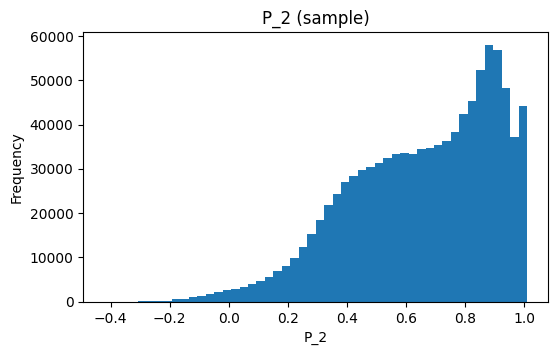

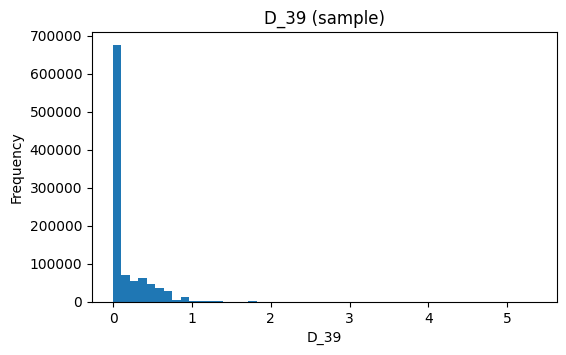

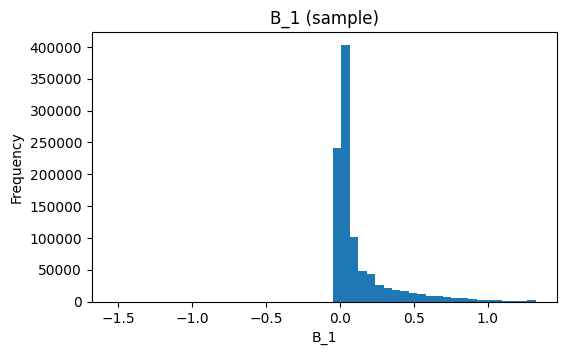

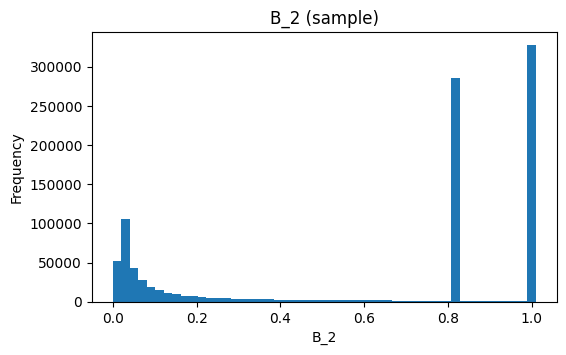

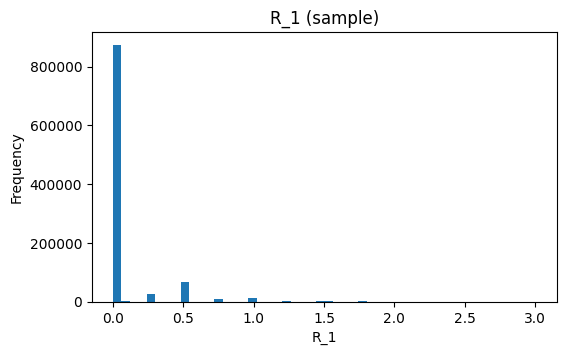

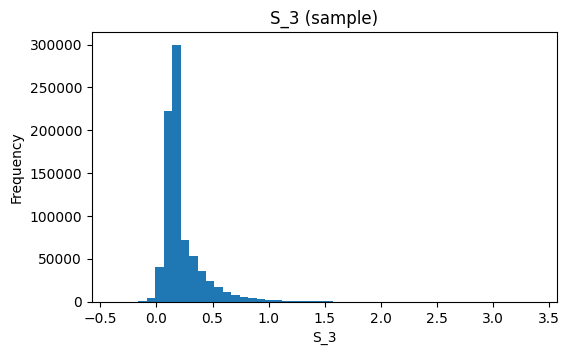

In [12]:
# EDA-6 — Histograms for a few numeric columns (from sample)
num_cols = [c for c in sample.columns if c not in ("customer_ID","S_2") and np.issubdtype(sample[c].dtype, np.number)]
pick = num_cols[:6]  # first few numerics; change to your favorites

for col in pick:
    s = sample[col].dropna()
    if len(s) == 0:
        continue
    plt.figure(figsize=(6,3.5))
    plt.hist(s.values, bins=50)
    plt.title(f"{col} (sample)")
    plt.xlabel(col); plt.ylabel("Frequency")
    plt.show()

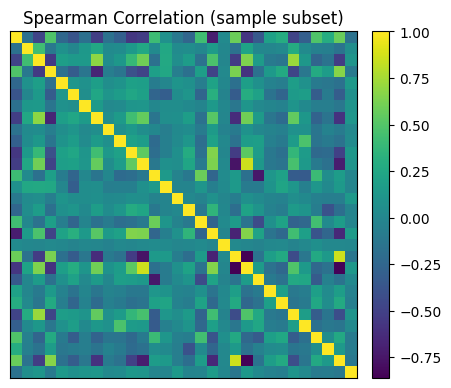

In [13]:
# EDA-7 — Correlation snapshot (Spearman) on a small numeric subset
sub = sample[num_cols].select_dtypes(include=[np.number]).copy()
sub = sub.iloc[:, :30]  # first 30 numeric cols to keep it light
sub = sub.fillna(sub.median(numeric_only=True))

corr = sub.corr(method="spearman").values
plt.figure(figsize=(5,4.5))
plt.imshow(corr, interpolation="nearest")
plt.title("Spearman Correlation (sample subset)")
plt.colorbar(fraction=0.046, pad=0.04)
plt.xticks([]); plt.yticks([])
plt.show()


# 1. LIGHT GBM (MODEL)

Importing the model

In [14]:
import lightgbm as lgb
print("LightGBM version:", lgb.__version__)

LightGBM version: 4.6.0


In [15]:
# Cell 2 — AMEX metric + LightGBM callback
import numpy as np

def amex_metric(y_true, y_pred):
    """Official AMEX metric (vectorized)."""
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(float)
    assert y_true.shape == y_pred.shape

    # Sort by prediction (desc)
    order = np.argsort(-y_pred, kind="mergesort")
    y_true = y_true[order]

    # Top 4% by weighted count (0 -> weight 20, 1 -> weight 1)
    weights = np.where(y_true == 0, 20, 1)
    cum_w = np.cumsum(weights)
    cutoff = int(0.04 * cum_w[-1])
    top_mask = cum_w <= cutoff
    top_four = y_true[top_mask].sum() / max(1, y_true.sum())

    # Normalized Gini
    def gini(a, p, w):
        order = np.argsort(-p, kind="mergesort")
        a, w = a[order], w[order]
        cum_w = np.cumsum(w)
        cum_y = np.cumsum(a * w)
        return (cum_y / cum_y[-1] - cum_w / cum_w[-1]).sum()

    den = gini(y_true, y_true, weights)
    g = gini(y_true, y_pred[order], weights) / (den if abs(den) > 1e-12 else 1e-12)

    return 0.5 * (g + top_four)

def lgb_amex_metric(preds, train_data):
    y = train_data.get_label()
    return ("amex", amex_metric(y, preds), True)


## Feature Engineering — Last Statement per Customer

**Why last-statement?**  
The dataset has multiple monthly statements per customer. A strong, fast baseline is to keep only
the most recent row per `customer_ID` (by `S_2`) and hash-encode any string categoricals to small integers.

**Pipeline (two passes, chunked):**
1. **Pass 1:** scan only `customer_ID,S_2` → get max date per customer.  
2. **Pass 2:** keep rows where `S_2 == max_date(customer_ID)`, break ties by last occurrence.  
3. Hash-encode categoricals → compact `int32`.  
4. Output: `train_df` (with `target`) and `test_agg` (same features).

This avoids GPU/CPU OOM while staying close to leaderboard-solid baselines.


In [16]:
# Cell 2 — Two-pass, chunked “last row per customer” build (memory-safe)
import os, gc, numpy as np, pandas as pd

DATA_DIR = "/kaggle/input/amex-default-prediction"
WORK_DIR = "/kaggle/working"
os.makedirs(WORK_DIR, exist_ok=True)

# ---------- helpers ----------
def _hash_series_to_int32_pandas(s: pd.Series, modulo: int = 2048) -> pd.Series:
    s = s.astype("string").fillna("__NA__")
    h = pd.util.hash_pandas_object(s, index=False).astype("int64")
    h = (h & 0x7FFFFFFF) % modulo
    return h.astype("int32")

def _pass1_max_date(csv_path: str, chunksize: int = 2_000_000):
    """
    Pass 1: read only customer_ID,S_2 to find the max S_2 per customer.
    Returns a dict: cid -> max_date (pd.Timestamp)
    """
    cid_to_max = {}
    for chunk in pd.read_csv(csv_path, usecols=["customer_ID","S_2"], chunksize=chunksize):
        chunk["S_2"] = pd.to_datetime(chunk["S_2"])
        # reduce within chunk
        grp = chunk.groupby("customer_ID", sort=False)["S_2"].max()
        for cid, dt in grp.items():
            if (cid not in cid_to_max) or (dt > cid_to_max[cid]):
                cid_to_max[cid] = dt
        del chunk, grp
        gc.collect()
    return cid_to_max

def _pass2_collect_last_rows(csv_path: str, cid_to_max: dict, chunksize: int = 1_000_000):
    """
    Pass 2: scan full CSV; keep rows where S_2 == cid_to_max[cid].
    If multiple rows per (cid, S_2_max), keep the LAST (tail(1)) in that chunk.
    Returns a pandas DataFrame with one row per customer (may still need final groupby).
    """
    # probe full schema to keep all feature columns
    sample = pd.read_csv(csv_path, nrows=2000)
    cols = list(sample.columns)

    kept_parts = []
    for chunk in pd.read_csv(csv_path, usecols=cols, chunksize=chunksize):
        chunk["S_2"] = pd.to_datetime(chunk["S_2"])
        # filter to rows that match that customer's max date
        # map lookup (vectorized): create a Series of max dates aligned to chunk cids
        max_dates = chunk["customer_ID"].map(cid_to_max)
        mask = (max_dates.notna()) & (chunk["S_2"].values == max_dates.values)
        if not mask.any():
            del chunk, max_dates
            gc.collect()
            continue
        sub = chunk.loc[mask].copy()
        # within this sub-chunk, keep last row per customer_ID
        sub = sub.sort_values(["customer_ID", "S_2"]).groupby("customer_ID", sort=False).tail(1)
        kept_parts.append(sub[cols])  # keep all columns
        del chunk, max_dates, sub
        gc.collect()

    if not kept_parts:
        return pd.DataFrame(columns=cols)

    df_last = pd.concat(kept_parts, axis=0, ignore_index=True)
    # In case same customer got split across chunks with same max date, finalize with tail(1)
    df_last = df_last.sort_values(["customer_ID", "S_2"]).groupby("customer_ID", sort=False).tail(1).reset_index(drop=True)
    return df_last

def _finalize_features_last(df_last: pd.DataFrame) -> pd.DataFrame:
    """
    Hash any non-numeric columns (except customer_ID, S_2), drop S_2.
    """
    for c in df_last.columns:
        if c in ("customer_ID", "S_2"):
            continue
        if not np.issubdtype(df_last[c].dtype, np.number):
            df_last[c] = _hash_series_to_int32_pandas(df_last[c], modulo=2048)
    return df_last.drop(columns=["S_2"])

def build_last_table(csv_path: str, label_df: pd.DataFrame | None = None, role: str = "train"):
    """
    role='train' → returns train_df (merged with labels)
    role='test'  → returns test_agg (customer_ID + features)
    """
    print(f"[{role}] pass 1: scanning max dates ...")
    cid_to_max = _pass1_max_date(csv_path)
    print(f"[{role}] unique customers found:", len(cid_to_max))

    print(f"[{role}] pass 2: collecting last rows ...")
    last_rows = _pass2_collect_last_rows(csv_path, cid_to_max)
    print(f"[{role}] last_rows shape:", last_rows.shape)

    print(f"[{role}] hashing categoricals & finalizing ...")
    last_feats = _finalize_features_last(last_rows)
    print(f"[{role}] finalized feature table:", last_feats.shape)

    if role == "train":
        assert label_df is not None, "label_df must be provided for role='train'"
        out = label_df.merge(last_feats, on="customer_ID", how="left")
        return out
    else:
        return last_feats

# ---------- TRAIN ----------
labels = pd.read_csv(f"{DATA_DIR}/train_labels.csv")  # customer_ID, target
train_df = build_last_table(f"{DATA_DIR}/train_data.csv", label_df=labels, role="train")

# ---------- TEST ----------
test_last = build_last_table(f"{DATA_DIR}/test_data.csv", label_df=None, role="test")

# Align columns to training features
feature_cols = [c for c in train_df.columns if c not in ("customer_ID","target")]
for col in feature_cols:
    if col not in test_last.columns:
        test_last[col] = np.nan
test_agg = test_last[["customer_ID"] + feature_cols]

print("Final shapes → train_df:", train_df.shape, " | test_agg:", test_agg.shape)
display(train_df.head())
display(test_agg.head())

# Medians for imputation in Cells 3 & 4
TRAIN_FEATURES_ONLY = train_df[feature_cols].replace([np.inf, -np.inf], np.nan).astype(np.float32)
train_medians = TRAIN_FEATURES_ONLY.median(numeric_only=True)
print(f"Medians computed for {len(train_medians)} features.")


[train] pass 1: scanning max dates ...
[train] unique customers found: 458913
[train] pass 2: collecting last rows ...
[train] last_rows shape: (458913, 190)
[train] hashing categoricals & finalizing ...
[train] finalized feature table: (458913, 189)
[test] pass 1: scanning max dates ...
[test] unique customers found: 924621
[test] pass 2: collecting last rows ...
[test] last_rows shape: (924621, 190)
[test] hashing categoricals & finalizing ...
[test] finalized feature table: (924621, 189)
Final shapes → train_df: (458913, 190)  | test_agg: (924621, 189)


,customer_ID,target,P_2,D_39,B_1,B_2,R_1,S_3,D_41,B_3,D_42,D_43,D_44,B_4,D_45,B_5,R_2,D_46,D_47,D_48,D_49,B_6,B_7,B_8,D_50,D_51,B_9,R_3,D_52,P_3,B_10,D_53,S_5,B_11,S_6,D_54,R_4,S_7,B_12,S_8,D_55,D_56,B_13,R_5,D_58,S_9,B_14,D_59,D_60,D_61,B_15,S_11,D_62,D_63,D_64,D_65,B_16,B_17,B_18,B_19,...,S_22,S_23,S_24,S_25,S_26,D_102,D_103,D_104,D_105,D_106,D_107,B_36,B_37,R_26,R_27,B_38,D_108,D_109,D_110,D_111,B_39,D_112,B_40,S_27,D_113,D_114,D_115,D_116,D_117,D_118,D_119,D_120,D_121,D_122,D_123,D_124,D_125,D_126,D_127,D_128,D_129,B_41,B_42,D_130,D_131,D_132,D_133,R_28,D_134,D_135,D_136,D_137,D_138,D_139,D_140,D_141,D_142,D_143,D_144,D_145
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,0,0.934745,0.009119,0.009382,1.007647,0.006104,0.135021,0.001604,0.007174,NaN,NaN,0.003258,0.070793,0.740102,0.231717,0.008309,0.420521,0.539715,0.192376,NaN,0.149564,0.058425,0.002927,0.153461,0.673522,0.009535,0.000085,0.203524,0.629392,0.326101,NaN,0.034643,0.010260,0.001770,1.008097,0.008517,0.105671,0.112294,0.488232,0.187285,0.166636,0.100107,0.009444,0.007174,0.007397,0.010239,0.063465,0.258461,0.227637,0.014553,0.402246,0.446568,887,1911,0.008656,0.006408,NaN,1.007897,0.005274,...,0.917811,0.131801,0.936067,0.971994,0.001281,0.943340,1.002457,1.014510,1.073985,NaN,0.671683,0.007441,0.008676,NaN,1.006130,2.0,NaN,0.000226,NaN,NaN,NaN,1.009372,0.100454,0.928955,0.003658,1.0,0.255787,0.0,4.0,0.260255,0.256656,0.0,0.719791,0.433844,0.003580,0.684978,0.008398,1.0,1.008338,0.999737,1.008523,0.003973,NaN,0.004186,0.005702,NaN,0.006210,0.002715,NaN,NaN,NaN,NaN,NaN,0.007186,0.004234,0.005086,NaN,0.005810,0.002970,0.008533
1,00000fd6641609c6ece5454664794f0340ad84dddce9a2...,0,0.880519,0.178126,0.034684,1.004028,0.006911,0.165509,0.005552,0.005068,NaN,0.060646,0.008781,0.020626,0.266275,0.027000,0.004976,0.438828,0.402195,0.014696,NaN,0.167634,0.028411,0.000974,NaN,0.339683,0.012926,0.102036,0.242366,0.570898,0.297130,NaN,0.043929,0.014570,0.002911,1.002821,0.003283,0.208516,0.019050,0.406434,0.036112,0.748383,0.017684,0.005880,0.009756,0.127805,0.018667,0.212538,0.411989,0.048978,0.009538,0.363754,0.233980,1182,1911,0.008747,0.002940,NaN,1.003602,0.008047,...,0.920889,0.132865,0.930629,0.977674,0.003213,0.001621,0.008952,0.004363,NaN,NaN,0.007774,0.007457,0.032899,NaN,1.007599,2.0,NaN,0.004743,NaN,NaN,NaN,1.006547,0.019811,0.292214,0.009312,1.0,0.454329,0.0,-1.0,0.446036,0.436884,0.0,0.551341,0.286821,0.008603,0.136650,0.009314,1.0,0.000229,0.999252,0.001777,0.002943,NaN,0.002202,0.001928,NaN,0.002996,0.001701,NaN,NaN,NaN,NaN,NaN,0.002980,0.007479,0.007870,NaN,0.003284,0.003169,0.008514
2,00001b22f846c82c51f6e3958ccd81970162bae8b007e8...,0,0.880875,0.009704,0.004284,0.812650,0.006450,NaN,0.003796,0.007196,NaN,NaN,0.000628,0.031044,0.251598,0.001557,0.001687,0.433713,0.339125,0.080370,NaN,0.183628,0.026981,0.000247,NaN,0.342118,0.009392,0.006264,0.202159,0.628938,0.296313,NaN,0.001824,0.005092,1.002365,1.005992,0.001983,NaN,0.007158,0.009188,0.098963,0.209386,0.001749,0.003000,0.002847,NaN,0.006699,0.213039,0.002820,0.137834,0.006031,0.280417,0.438647,1182,39,0.000845,0.007836,NaN,1.004080,0.005951,...,0.302868,0.132692,0.086479,0.972368,0.004705,0.009786,0.003091,0.005433,NaN,NaN,0.000847,0.005196,0.004723,NaN,1.003010,1.0,NaN,0.009816,NaN,NaN,NaN,1.007076,0.024902,NaN,0.000257,1.0,0.388621,0.0,-1.0,0.368051,0.369018,0.0,0.444615,0.149832,0.004057,0.275856,0.004732,1.0,0.009514,0.008331,0.004189,0.004133,NaN,0.002654,0.003470,NaN,0.009881,0.007691,NaN,NaN,NaN,NaN,NaN,0.007383,0.006623,0.000964,NaN,0.002202,0.000834,0.003444
3,000041bdba6ecadd89a52d11886e8eaaec9325906c9723...,0,0.621776,0.001083,0.012564,1.006183,0.007829,0.287766,0.004532,0.009937,NaN,0.046104,0.007792,0.007235,0.085103,0.118818,0.004238,0.410723,0.414224,NaN,NaN,0.174331,0.011969,1.005561,0.430318,0.333342,0.020526,0.204338,0.198356,0.672080,0.411625,0.001379,0.022970,0.005491,0.001113,1.004073,0.008534,0.279464,0.074835,0.170538,0.021400,0.554483,0.055897,0.001347,0.009294,0.011429,0.01

,customer_ID,P_2,D_39,B_1,B_2,R_1,S_3,D_41,B_3,D_42,D_43,D_44,B_4,D_45,B_5,R_2,D_46,D_47,D_48,D_49,B_6,B_7,B_8,D_50,D_51,B_9,R_3,D_52,P_3,B_10,D_53,S_5,B_11,S_6,D_54,R_4,S_7,B_12,S_8,D_55,D_56,B_13,R_5,D_58,S_9,B_14,D_59,D_60,D_61,B_15,S_11,D_62,D_63,D_64,D_65,B_16,B_17,B_18,B_19,D_66,...,S_22,S_23,S_24,S_25,S_26,D_102,D_103,D_104,D_105,D_106,D_107,B_36,B_37,R_26,R_27,B_38,D_108,D_109,D_110,D_111,B_39,D_112,B_40,S_27,D_113,D_114,D_115,D_116,D_117,D_118,D_119,D_120,D_121,D_122,D_123,D_124,D_125,D_126,D_127,D_128,D_129,B_41,B_42,D_130,D_131,D_132,D_133,R_28,D_134,D_135,D_136,D_137,D_138,D_139,D_140,D_141,D_142,D_143,D_144,D_145
0,00000469ba478561f23a92a868bd366de6f6527a684c9a...,0.568930,0.121385,0.010779,1.009347,0.006923,0.149413,0.000396,0.003576,0.103745,0.007398,0.006787,0.124780,0.025111,0.050187,0.007511,0.445881,0.489448,0.517214,NaN,0.024945,0.163441,1.008730,NaN,0.333484,0.005263,0.109464,0.115930,0.560515,0.033599,NaN,0.011795,0.005188,0.003473,1.007686,0.005607,0.159703,0.058696,0.464023,0.458377,NaN,0.063506,0.005444,0.381320,0.016998,0.008621,0.424651,0.013835,0.589184,0.014091,1.767255,0.049326,887,936,0.001363,0.002311,NaN,0.590569,0.003994,NaN,...,0.980107,0.135788,0.957597,0.970630,0.080587,0.003999,0.003953,0.006018,NaN,NaN,0.000153,0.001118,0.007948,NaN,1.002286,2.0,NaN,0.000151,NaN,NaN,NaN,1.007009,0.375581,0.346436,0.009603,0.0,0.251319,0.0,-1.0,0.247260,0.253784,1.0,0.199254,0.144025,0.004272,0.009896,0.000478,0.0,0.009689,0.001736,0.009961,0.006789,NaN,0.004902,0.000975,NaN,0.006273,0.008816,NaN,NaN,NaN,NaN,NaN,0.005912,0.001250,0.006543,NaN,0.009160,0.003690,0.003219
1,00001bf2e77ff879fab36aa4fac689b9ba411dae63ae39...,0.841177,0.126475,0.016562,1.009245,0.009715,0.112195,0.006192,0.011386,NaN,NaN,0.004234,0.014831,0.099732,0.135907,0.002269,0.445957,0.362383,0.041712,NaN,0.182720,0.014466,1.008640,NaN,0.001505,0.017454,0.008152,0.143998,0.525659,0.298735,NaN,0.009336,0.002235,0.005253,1.003089,0.008385,0.081717,0.054184,0.768435,0.053444,0.063766,0.058585,0.004132,0.006375,0.018508,0.010847,0.608682,0.685577,0.046726,0.005461,0.128330,0.330806,1182,1911,0.000348,0.091107,NaN,1.005304,0.003039,NaN,...,0.928590,0.135659,0.939332,0.974450,0.020564,0.007385,0.006146,0.004748,NaN,NaN,0.002687,0.007424,0.012894,NaN,1.000501,2.0,NaN,0.006356,NaN,NaN,NaN,1.003549,0.005498,0.590974,0.000565,1.0,0.317455,0.0,3.0,0.316734,0.318151,0.0,0.854850,0.578802,0.000412,0.645458,0.005065,1.0,0.009554,0.999368,0.001249,0.007340,NaN,0.001252,0.007632,NaN,0.002767,0.008789,NaN,NaN,NaN,NaN,NaN,0.004344,0.000866,0.009120,NaN,0.002196,0.000247,0.007780
2,0000210045da4f81e5f122c6bde5c2a617d03eef67f82c...,0.697522,0.002724,0.001484,0.810072,0.002620,0.166165,0.004888,0.015938,NaN,0.105303,0.003381,0.417713,0.068810,0.004851,0.000715,0.702994,0.204331,0.522954,NaN,0.058534,0.090228,1.009375,NaN,0.006962,0.008629,0.001312,0.235105,0.566616,0.129189,NaN,0.004455,0.003380,0.001847,1.003348,0.001102,0.170267,0.052914,0.123005,0.418986,NaN,0.048129,0.006620,0.272541,0.009170,0.004427,0.153307,0.003803,0.508047,0.006497,0.889807,0.520753,887,936,0.006646,0.006028,NaN,0.585974,0.001526,1.0,...,0.041972,0.133058,0.044327,0.970232,0.004460,0.336426,1.002226,0.965552,0.287646,NaN,0.340769,0.004671,0.005816,NaN,1.004291,2.0,NaN,0.005337,NaN,NaN,NaN,1.005360,0.096783,0.007752,0.409876,0.0,0.079162,0.0,3.0,0.079331,0.079235,0.0,0.279283,0.286200,0.002640,0.279715,0.004596,0.0,0.003059,0.005124,0.009323,0.007062,NaN,1.003890,0.001152,NaN,0.002045,0.001852,NaN,NaN,NaN,NaN,NaN,1.001246,0.008894,0.896224,0.150203,1.009391,0.457819,0.092041
3,00003b41e58ede33b8daf61ab56d9952f17c9ad1c3976c...,0.513186,0.324828,0.149511,0.205678,0.002278,0.181200,0.005813,0.498516,NaN,0.211615,0.258627,0.244689,0.237480,0.022947,0.009116,0.414899,0.171934,0.602520,NaN,0.023546,0.206215,0.009775,NaN,0.004042,0.185255,0.104179,0.078085,0.628619,0.032124,NaN,0.320184,0.139062,0.008872,1.005929,0.003604,0.552729,0.098741,0.478986,0.524700,NaN,0.147453,0.002603,0.516813,0.0

Medians computed for 188 features.


In [17]:
print(f"train_df: {train_df.shape}  |  test_agg: {test_agg.shape}")
display(train_df.head(3))

train_df: (458913, 190)  |  test_agg: (924621, 189)


,customer_ID,target,P_2,D_39,B_1,B_2,R_1,S_3,D_41,B_3,D_42,D_43,D_44,B_4,D_45,B_5,R_2,D_46,D_47,D_48,D_49,B_6,B_7,B_8,D_50,D_51,B_9,R_3,D_52,P_3,B_10,D_53,S_5,B_11,S_6,D_54,R_4,S_7,B_12,S_8,D_55,D_56,B_13,R_5,D_58,S_9,B_14,D_59,D_60,D_61,B_15,S_11,D_62,D_63,D_64,D_65,B_16,B_17,B_18,B_19,...,S_22,S_23,S_24,S_25,S_26,D_102,D_103,D_104,D_105,D_106,D_107,B_36,B_37,R_26,R_27,B_38,D_108,D_109,D_110,D_111,B_39,D_112,B_40,S_27,D_113,D_114,D_115,D_116,D_117,D_118,D_119,D_120,D_121,D_122,D_123,D_124,D_125,D_126,D_127,D_128,D_129,B_41,B_42,D_130,D_131,D_132,D_133,R_28,D_134,D_135,D_136,D_137,D_138,D_139,D_140,D_141,D_142,D_143,D_144,D_145
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,0,0.934745,0.009119,0.009382,1.007647,0.006104,0.135021,0.001604,0.007174,NaN,NaN,0.003258,0.070793,0.740102,0.231717,0.008309,0.420521,0.539715,0.192376,NaN,0.149564,0.058425,0.002927,0.153461,0.673522,0.009535,0.000085,0.203524,0.629392,0.326101,NaN,0.034643,0.010260,0.001770,1.008097,0.008517,0.105671,0.112294,0.488232,0.187285,0.166636,0.100107,0.009444,0.007174,0.007397,0.010239,0.063465,0.258461,0.227637,0.014553,0.402246,0.446568,887,1911,0.008656,0.006408,NaN,1.007897,0.005274,...,0.917811,0.131801,0.936067,0.971994,0.001281,0.943340,1.002457,1.014510,1.073985,NaN,0.671683,0.007441,0.008676,NaN,1.006130,2.0,NaN,0.000226,NaN,NaN,NaN,1.009372,0.100454,0.928955,0.003658,1.0,0.255787,0.0,4.0,0.260255,0.256656,0.0,0.719791,0.433844,0.003580,0.684978,0.008398,1.0,1.008338,0.999737,1.008523,0.003973,NaN,0.004186,0.005702,NaN,0.006210,0.002715,NaN,NaN,NaN,NaN,NaN,0.007186,0.004234,0.005086,NaN,0.005810,0.002970,0.008533
1,00000fd6641609c6ece5454664794f0340ad84dddce9a2...,0,0.880519,0.178126,0.034684,1.004028,0.006911,0.165509,0.005552,0.005068,NaN,0.060646,0.008781,0.020626,0.266275,0.027000,0.004976,0.438828,0.402195,0.014696,NaN,0.167634,0.028411,0.000974,NaN,0.339683,0.012926,0.102036,0.242366,0.570898,0.297130,NaN,0.043929,0.014570,0.002911,1.002821,0.003283,0.208516,0.019050,0.406434,0.036112,0.748383,0.017684,0.005880,0.009756,0.127805,0.018667,0.212538,0.411989,0.048978,0.009538,0.363754,0.233980,1182,1911,0.008747,0.002940,NaN,1.003602,0.008047,...,0.920889,0.132865,0.930629,0.977674,0.003213,0.001621,0.008952,0.004363,NaN,NaN,0.007774,0.007457,0.032899,NaN,1.007599,2.0,NaN,0.004743,NaN,NaN,NaN,1.006547,0.019811,0.292214,0.009312,1.0,0.454329,0.0,-1.0,0.446036,0.436884,0.0,0.551341,0.286821,0.008603,0.136650,0.009314,1.0,0.000229,0.999252,0.001777,0.002943,NaN,0.002202,0.001928,NaN,0.002996,0.001701,NaN,NaN,NaN,NaN,NaN,0.002980,0.007479,0.007870,NaN,0.003284,0.003169,0.008514
2,00001b22f846c82c51f6e3958ccd81970162bae8b007e8...,0,0.880875,0.009704,0.004284,0.812650,0.006450,NaN,0.003796,0.007196,NaN,NaN,0.000628,0.031044,0.251598,0.001557,0.001687,0.433713,0.339125,0.080370,NaN,0.183628,0.026981,0.000247,NaN,0.342118,0.009392,0.006264,0.202159,0.628938,0.296313,NaN,0.001824,0.005092,1.002365,1.005992,0.001983,NaN,0.007158,0.009188,0.098963,0.209386,0.001749,0.003000,0.002847,NaN,0.006699,0.213039,0.002820,0.137834,0.006031,0.280417,0.438647,1182,39,0.000845,0.007836,NaN,1.004080,0.005951,...,0.302868,0.132692,0.086479,0.972368,0.004705,0.009786,0.003091,0.005433,NaN,NaN,0.000847,0.005196,0.004723,NaN,1.003010,1.0,NaN,0.009816,NaN,NaN,NaN,1.007076,0.024902,NaN,0.000257,1.0,0.388621,0.0,-1.0,0.368051,0.369018,0.0,0.444615,0.149832,0.004057,0.275856,0.004732,1.0,0.009514,0.008331,0.004189,0.004133,NaN,0.002654,0.003470,NaN,0.009881,0.007691,NaN,NaN,NaN,NaN,NaN,0.007383,0.006623,0.000964,NaN,0.002202,0.000834,0.003444


## Training — LightGBM (GPU) + AMEX Metric

**Setup**
- Loss: `binary_logloss`
- Metric shown: AMEX (custom callback)
- Early stopping via callbacks (patience = 200)
- Regularization & speed: `num_leaves=128`, `min_data_in_leaf=100`, `feature_fraction=0.4`, `bagging_fraction=0.8`, `max_bin=255`
- Device: **GPU**

We split 80/20 stratified, impute medians, and let early stopping find the best iteration.


In [18]:
# Cell 3 — Train LightGBM (GPU) with callbacks early stopping
import lightgbm as lgb
from sklearn.model_selection import train_test_split
import numpy as np

print("LightGBM version:", lgb.__version__)

assert "train_df" in globals(), "Expected a DataFrame named train_df from your preprocessing step."

FEATURES = [c for c in train_df.columns if c not in ("customer_ID", "target")]
TARGET = "target"

X = train_df[FEATURES].replace([np.inf, -np.inf], np.nan).astype(np.float32)
# Use medians computed in Cell 2 if available; otherwise compute now
if "train_medians" not in globals():
    train_medians = X.median(numeric_only=True)
X = X.fillna(train_medians)
y = train_df[TARGET].astype(np.int8)

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Valid: {X_valid.shape}, Features: {len(FEATURES)}")

train_set = lgb.Dataset(X_train, label=y_train, free_raw_data=False)
valid_set = lgb.Dataset(X_valid, label=y_valid, reference=train_set, free_raw_data=False)

params = {
    "objective": "binary",
    "metric": "binary_logloss",     # AMEX reported via feval
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves": 128,
    "min_data_in_leaf": 100,
    "feature_fraction": 0.4,
    "bagging_fraction": 0.8,
    "bagging_freq": 1,
    "max_depth": -1,
    "lambda_l1": 1.0,
    "lambda_l2": 2.0,
    "max_bin": 255,
    "bin_construct_sample_cnt": 200_000,
    "device": "gpu",                # GPU
    "gpu_platform_id": 0,
    "gpu_device_id": 0,
    # If you hit OOM on GPU, try:
    # "force_col_wise": True,
}

# Use callbacks for early stopping & logging (compatible across LGBM versions)
callbacks = [
    lgb.early_stopping(stopping_rounds=200, verbose=True),
    lgb.log_evaluation(period=200),
]

model = lgb.train(
    params=params,
    train_set=train_set,
    num_boost_round=5000,
    valid_sets=[train_set, valid_set],
    valid_names=["train", "valid"],
    feval=lgb_amex_metric,          # from Cell 2
    callbacks=callbacks
)

# Validation AMEX
valid_pred = model.predict(X_valid, num_iteration=model.best_iteration or model.current_iteration())
print("AMEX (valid):", amex_metric(y_valid.values.astype(int), valid_pred))
print("Best iteration:", model.best_iteration or model.current_iteration())


LightGBM version: 4.6.0
Train: (367130, 188), Valid: (91783, 188), Features: 188
[LightGBM] [Info] Number of positive: 95062, number of negative: 272068
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 44673
[LightGBM] [Info] Number of data points in the train set: 367130, number of used features: 186
[LightGBM] [Info] Using requested OpenCL platform 0 device 0
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 157 dense feature groups (56.02 MB) transferred to GPU in 0.060155 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.258933 -> initscore=-1.051523
[LightGBM] [Info] Start training from score -1.051523
Training until validation scores don't improve for 200 rounds
[200]	train's binary_logloss: 0.192752	train's amex: 0.837909	valid's binary_logloss: 0.219884	valid's amex: 0.789228
[400]	train's binary_logloss: 0.163595	train's amex: 0.888668	valid's binary_logloss: 0.218856	valid's amex: 0.789654
Early stopping, best iteration is:
[226]	train's binary_logloss: 0.188366	train's amex: 0.845591	valid's binary_logloss: 0.219551	valid's amex: 0.790611
AMEX (valid): 0.7906114413845218
Best iteration: 226


In [19]:
print(f"Best iteration: {getattr(model, 'best_iteration', None) or model.current_iteration()}")
# Optional: quick top-20 feature importances
import pandas as pd
imp = pd.DataFrame({
    "feature": FEATURES,
    "gain": model.feature_importance(importance_type="gain")
}).sort_values("gain", ascending=False).head(20)
display(imp)

Best iteration: 226


,feature,gain
0,P_2,595181.135464
24,B_9,231947.728400
10,D_44,178656.627033
3,B_2,128051.588106
17,D_48,116267.620962
2,B_1,89582.419981
4,R_1,80952.733331
7,B_3,79272.568647
5,S_3,39097.893855
1,D_39,31981.641309


## Inference & Submission

We align predictions to `sample_submission.csv` order by `customer_ID` to avoid any ID/order mismatch,
then write the final CSV to `/kaggle/working/`.


In [20]:
# Cell 4 — Inference & submission (GPU-trained model)

import numpy as np
import pandas as pd

# Sanity checks
assert "test_agg" in globals(), "Expected test_agg from Cell 2."
assert "FEATURES" in globals(), "Run Cell 3 first to define FEATURES."
assert "model" in globals(), "Run Cell 3 to train the model."
assert "train_medians" in globals(), "Expected train_medians from Cell 2/3."

# Align test columns to training FEATURES
for col in FEATURES:
    if col not in test_agg.columns:
        test_agg[col] = np.nan

X_test = test_agg[FEATURES].replace([np.inf, -np.inf], np.nan).astype(np.float32)
X_test = X_test.fillna(train_medians)

# Use best iteration if available, else current
best_it = getattr(model, "best_iteration", None) or getattr(model, "current_iteration", lambda: None)()
test_pred = model.predict(X_test, num_iteration=best_it)

# Build and save submission
DATA_DIR = "/kaggle/input/amex-default-prediction"
sub = pd.read_csv(f"{DATA_DIR}/sample_submission.csv", usecols=["customer_ID"])
sub["prediction"] = test_pred

out_path = "/kaggle/working/submission.csv"
sub.to_csv(out_path, index=False)
print("Saved:", out_path)

# Quick peek
display(sub.head())


Saved: /kaggle/working/submission.csv


,customer_ID,prediction
0,00000469ba478561f23a92a868bd366de6f6527a684c9a...,0.023498
1,00001bf2e77ff879fab36aa4fac689b9ba411dae63ae39...,0.001596
2,0000210045da4f81e5f122c6bde5c2a617d03eef67f82c...,0.057506
3,00003b41e58ede33b8daf61ab56d9952f17c9ad1c3976c...,0.348630
4,00004b22eaeeeb0ec976890c1d9bfc14fd9427e98c4ee9...,0.839151


**Submission created ✅**  
Upload `/kaggle/working/submission_lgbm_gpu.csv` to Kaggle to score on the leaderboard.


## 2. Random Forest (Model)

## Processing Train Data ##
- Split Train data to 20 parts
- Split Test data to 20 parts
- Prevent memory error during processing
- Use GPU

In [21]:
# # CALCULATE SIZE OF EACH SEPARATE FILE
# def get_rows(customers, train, NUM_FILES = 20, verbose = ''):
#     chunk = len(customers)//NUM_FILES
#     if verbose != '':
#         print(f'We will split {verbose} data into {NUM_FILES} separate files.')
#         print(f'There will be {chunk} customers in each file (except the last file).')
#         print('Below are number of rows in each file:')
#     rows = []

#     for k in range(NUM_FILES):
#         if k==NUM_FILES-1: cc = customers[k*chunk:]
#         else: cc = customers[k*chunk:(k+1)*chunk]
#         s = train.loc[train.customer_ID.isin(cc)].shape[0]
#         rows.append(s)
#     if verbose != '': print( rows )
#     return rows

# if PROCESS_DATA:
#     NUM_FILES = 20
#     rows = get_rows(customers, train, NUM_FILES = NUM_FILES, verbose = 'train')

1. customer_ID
- Original: 64 bytes (string of length 64)
- Reduced: 8 bytes (int64)

3. S_2 (Date with time)
- Original: 10 bytes (string)
- Reduced: 3 bytes (datetime object)

4. 11 Categorical Columns
- Original: 8 bytes (int64)
- Reduced: 1 bytes (int8)
- Columns: ['B_30', 'B_38', 'D_114', 'D_116', 'D_117', 'D_120', 'D_126', 'D_63', 'D_64', 'D_66', 'D_68']


5. 177 Numeric Columns
- Original: 1416 bytes (float64)
- Reduced: 708 bytes (float32)

6. Specific column (B_31): Convert to int8 (1 byte) since it has only 2 values.

In [22]:
# def feature_engineer(train, PAD_CUSTOMER_TO_13_ROWS = True, targets = None):
        
#     # REDUCE STRING COLUMNS 
#     # from 64 bytes to 8 bytes, and 10 bytes to 3 bytes respectively
#     train['customer_ID'] = train['customer_ID'].str[-16:].str.hex_to_int().astype('int64')
#     train.S_2 = cudf.to_datetime( train.S_2 )
#     train['year'] = (train.S_2.dt.year-2000).astype('int8')
#     train['month'] = (train.S_2.dt.month).astype('int8')
#     train['day'] = (train.S_2.dt.day).astype('int8')
#     del train['S_2']
        
#     # LABEL ENCODE CAT COLUMNS (and reduce to 1 byte)
#     # with 0: padding, 1: nan, 2,3,4,etc: values
#     d_63_map = {'CL':2, 'CO':3, 'CR':4, 'XL':5, 'XM':6, 'XZ':7}
#     train['D_63'] = train.D_63.map(d_63_map).fillna(1).astype('int8')

#     d_64_map = {'-1':2,'O':3, 'R':4, 'U':5}
#     train['D_64'] = train.D_64.map(d_64_map).fillna(1).astype('int8')
    
#     CATS = ['B_30', 'B_38', 'D_114', 'D_116', 'D_117', 'D_120', 'D_126', 'D_66', 'D_68']
#     OFFSETS = [2,1,2,2,3,2,3,2,2] #2 minus minimal value in full train csv
#     # then 0 will be padding, 1 will be NAN, 2,3,4,etc will be values
#     for c,s in zip(CATS,OFFSETS):
#         train[c] = train[c] + s
#         train[c] = train[c].fillna(1).astype('int8')
#     CATS += ['D_63','D_64']
    
#     # ADD NEW FEATURES HERE
#     # EXAMPLE: train['feature_189'] = etc etc etc
#     # EXAMPLE: train['feature_190'] = etc etc etc
#     # IF CATEGORICAL, THEN ADD TO CATS WITH: CATS += ['feaure_190'] etc etc etc
    
#     # REDUCE MEMORY DTYPE
#     SKIP = ['customer_ID','year','month','day']
#     for c in train.columns:
#         if c in SKIP: continue
#         if str( train[c].dtype )=='int64':
#             train[c] = train[c].astype('int32')
#         if str( train[c].dtype )=='float64':
#             train[c] = train[c].astype('float32')
            
#     # PAD ROWS SO EACH CUSTOMER HAS 13 ROWS
#     if PAD_CUSTOMER_TO_13_ROWS:
#         tmp = train[['customer_ID']].groupby('customer_ID').customer_ID.agg('count')
#         more = cupy.array([],dtype='int64') 
#         for j in range(1,13):
#             i = tmp.loc[tmp==j].index.values
#             more = cupy.concatenate([more,cupy.repeat(i,13-j)])
#         df = train.iloc[:len(more)].copy().fillna(0)
#         df = df * 0 - 1 #pad numerical columns with -1
#         df[CATS] = (df[CATS] * 0).astype('int8') #pad categorical columns with 0
#         df['customer_ID'] = more
#         train = cudf.concat([train,df],axis=0,ignore_index=True)
        
#     # ADD TARGETS (and reduce to 1 byte)
#     if targets is not None:
#         train = train.merge(targets,on='customer_ID',how='left')
#         train.target = train.target.astype('int8')
        
#     # FILL NAN
#     train = train.fillna(-0.5) #this applies to numerical columns
    
#     # SORT BY CUSTOMER THEN DATE
#     train = train.sort_values(['customer_ID','year','month','day']).reset_index(drop=True)
#     train = train.drop(['year','month','day'],axis=1)
    
#     # REARRANGE COLUMNS WITH 11 CATS FIRST
#     COLS = list(train.columns[1:])
#     COLS = ['customer_ID'] + CATS + [c for c in COLS if c not in CATS]
#     train = train[COLS]
    
#     return train

## Training — Random Forest (GPU/CPU)

We train a Random Forest as a strong non-boosting baseline.
- **GPU option (cuML RandomForestClassifier)** — fast on Kaggle GPU for larger tabular sets.
- **CPU option (sklearn RandomForestClassifier)** — portable and simple.

For evaluation we use the **AMEX metric** on the same validation split as LightGBM.


In [23]:
PROCESS_DATA = True
USE_GPU = True             # True: cuML RF on GPU, False: sklearn RF on CPU
MAKE_FEATURES = 'agg'      # 'last', 'agg', or 'flat13'
RANDOM_STATE = 26
TEST_SIZE = 0.25

In [24]:
def make_dataset_from_engineered(train_engineered, make=MAKE_FEATURES):
    has_target = 'target' in train_engineered.columns
    COLS = list(train_engineered.columns)
    CATS = COLS[1:1+11]
    ALL = COLS[1:]
    NUMS = [c for c in ALL if c not in CATS + (['target'] if has_target else [])]

    g = train_engineered.groupby('customer_ID')

    if make == 'last':
        df = g.tail(1)
        y = df['target'].values if has_target else None
        X = df.drop(columns=['target']) if has_target else df
        return X.set_index('customer_ID'), y, list(X.columns)

    elif make == 'agg':
        num_agg = g[NUMS].agg(['last','mean','std','min','max'])
        cat_last = g[CATS].agg('last')
        X = cat_last.join(num_agg)
        X.columns = [f"{a}__{b}" if isinstance(a, tuple) else a for a in X.columns]
        y = g['target'].agg('last').values if has_target else None
        return X, y, list(X.columns)

    elif make == 'flat13':
        df = train_engineered.copy()
        if has_target:
            df_target = df[['customer_ID','target']].groupby('customer_ID').tail(1).drop_duplicates().set_index('customer_ID')
            df = df.drop(columns=['target'])
        df['_row'] = (df.groupby('customer_ID').cumcount()).astype('int8')
        piv = df.pivot(index='customer_ID', columns='_row')
        piv.columns = [f'{c[0]}@t{int(c[1])}' for c in piv.columns]
        X = piv
        y = df_target.loc[X.index,'target'].values if has_target else None
        return X, y, list(X.columns)


In [25]:

import os, gc, sys, glob, warnings, json
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import joblib

# ---------------- CONFIG ----------------
INPUT_DIR  = "/kaggle/input/amex-default-prediction"
WORK_DIR   = "/kaggle/working"
TMP_DIR    = os.path.join(WORK_DIR, "lastsnap-temp")
CACHE_DIR  = os.path.join(WORK_DIR, "lastsnap-cache")
os.makedirs(TMP_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

TRAIN_CSV  = os.path.join(INPUT_DIR, "train_data.csv")
TEST_CSV   = os.path.join(INPUT_DIR,  "test_data.csv")
LABELS_CSV = os.path.join(INPUT_DIR, "train_labels.csv")

# Cache files (reused across runs)
TRAIN_LAST_PQT = os.path.join(CACHE_DIR, "train_last_snapshot.parquet")
TEST_LAST_PQT  = os.path.join(CACHE_DIR, "test_last_snapshot.parquet")

# Chunking + split
CHUNKSIZE   = 1_000_000      # lower if you still see restarts: 700_000 or 500_000
VALID_SIZE  = 0.25
RANDOM_STATE = 26

# RandomForest (kept modest to stay RAM-safe)
RF_PARAMS = dict(
    n_estimators=400,
    max_depth=28,
    max_features="sqrt",
    min_samples_split=4,
    min_samples_leaf=1,
    bootstrap=True,
    n_jobs=-1,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)

# Categorical maps / encodes (same meaning as your GPU pipeline)
CATS_BASE   = ['B_30','B_38','D_114','D_116','D_117','D_120','D_126','D_66','D_68']
OFFSETS     = [2,      1,      2,      2,      3,      2,      3,      2,      2]
D63_MAP     = {'CL':2, 'CO':3, 'CR':4, 'XL':5, 'XM':6, 'XZ':7}
D64_MAP     = {'-1':2, 'O':3, 'R':4, 'U':5}

# ---------------- Helpers ----------------
def _id_hex_to_int16(s):
    return int(str(s)[-16:], 16)

def amex_metric(y_true, y_prob):
    """
    Official AMEX metric implementation (vectorized, RAM-safe for our split sizes).
    """
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_prob)

    # normalize ranks and weights
    w = np.where(y_true == 0, 20, 1)

    # top 4% by prediction
    order = np.argsort(-y_pred)
    w_cum = np.cumsum(w[order]) / np.sum(w)
    top4 = y_true[order][w_cum <= 0.04]
    d = np.sum(top4) / np.sum(y_true)

    # gini
    def _gini(a, p, w):
        order = np.argsort(-p)
        a, w = a[order], w[order]
        cum_w = np.cumsum(w)
        cum_a = np.cumsum(a * w)
        sum_a = np.sum(a * w)
        g = np.sum(cum_a / sum_a * w) / np.sum(w) - (np.sum(cum_w / np.sum(w) * w) / np.sum(w))
        return g

    g = _gini(y_true, y_pred, w)
    gmax = _gini(y_true, y_true, w)
    return 0.5 * (g / gmax + d)

def feature_engineer_chunk(df, keep_time=True):
    """
    Lean CPU version of your feature_engineer WITHOUT padding.
    """
    df['customer_ID'] = df['customer_ID'].astype(str).str[-16:].apply(_id_hex_to_int16).astype('int64')

    df['S_2'] = pd.to_datetime(df['S_2'])
    df['year']  = (df['S_2'].dt.year - 2000).astype('int16')
    df['month'] = df['S_2'].dt.month.astype('int8')
    df['day']   = df['S_2'].dt.day.astype('int8')

    if 'D_63' in df.columns:
        df['D_63'] = df['D_63'].map(D63_MAP).fillna(1).astype('int16')
    if 'D_64' in df.columns:
        df['D_64'] = df['D_64'].map(D64_MAP).fillna(1).astype('int16')

    for c, s in zip(CATS_BASE, OFFSETS):
        if c in df.columns:
            x = pd.to_numeric(df[c], errors='coerce')
            x = (x + s).astype('float32')
            df[c] = x.fillna(1).astype('int16')

    skip = {'customer_ID','S_2','year','month','day','target'}
    for c in df.columns:
        if c in skip: continue
        if pd.api.types.is_integer_dtype(df[c]):
            df[c] = pd.to_numeric(df[c], downcast='integer')
        elif pd.api.types.is_float_dtype(df[c]):
            df[c] = pd.to_numeric(df[c], downcast='float')

    num_cols = [c for c in df.columns if c not in ['customer_ID','S_2','year','month','day','target']]
    df[num_cols] = df[num_cols].fillna(-0.5)

    if not keep_time:
        df = df.drop(columns=['S_2','year','month','day'])

    return df

def write_chunk_last_rows(csv_path, prefix, chunksize=CHUNKSIZE):
    # clean any previous temp parts for this prefix
    for p in glob.glob(os.path.join(TMP_DIR, f"{prefix}_last_part_*.parquet")):
        try: os.remove(p)
        except: pass

    i = 0
    for chunk in pd.read_csv(csv_path, chunksize=chunksize, low_memory=False):
        fe = feature_engineer_chunk(chunk, keep_time=True)
        idx = fe.groupby('customer_ID')['S_2'].idxmax()
        last_rows = fe.loc[idx].copy()
        outp = os.path.join(TMP_DIR, f"{prefix}_last_part_{i}.parquet")
        last_rows.to_parquet(outp, index=False)
        print(f"[{prefix}] wrote {os.path.basename(outp)}  (rows={len(last_rows):,})")
        i += 1
        del chunk, fe, last_rows
        gc.collect()
    return i

def build_global_last(prefix):
    parts = sorted(glob.glob(os.path.join(TMP_DIR, f"{prefix}_last_part_*.parquet")))
    if not parts:
        raise FileNotFoundError(f"No parts found for prefix={prefix}")

    dfs = []
    for p in parts:
        dfp = pd.read_parquet(p)
        dfs.append(dfp)
    big = pd.concat(dfs, ignore_index=True)
    del dfs; gc.collect()

    idx = big.groupby('customer_ID')['S_2'].idxmax()
    last_global = big.loc[idx].copy()

    last_global = last_global.sort_values('customer_ID')
    last_global = last_global.drop(columns=['S_2','year','month','day'])
    last_global = last_global.set_index('customer_ID')

    # optional: clean temp
    for p in parts:
        try: os.remove(p)
        except: pass

    return last_global

# ---------------- Main ----------------
def main():
    # TRAIN last snapshot cache
    if os.path.exists(TRAIN_LAST_PQT):
        print(">> Loading cached TRAIN last snapshot…")
        X_train = pd.read_parquet(TRAIN_LAST_PQT).set_index('customer_ID')
    else:
        print(">> Processing TRAIN chunks to LAST rows…")
        write_chunk_last_rows(TRAIN_CSV, prefix="train")
        print(">> Building global TRAIN last snapshot…")
        X_train = build_global_last(prefix="train")
        X_train.reset_index().to_parquet(TRAIN_LAST_PQT, index=False)
    print("   train per-customer shape:", X_train.shape)

    # Labels
    labels = pd.read_csv(LABELS_CSV)
    labels['customer_ID'] = labels['customer_ID'].astype(str).str[-16:].apply(_id_hex_to_int16).astype('int64')
    labels = labels.set_index('customer_ID')
    y = labels.reindex(X_train.index)['target'].astype('int8').values

    # Split
    X_tr, X_va, y_tr, y_va = train_test_split(
        X_train, y, test_size=VALID_SIZE, random_state=RANDOM_STATE, stratify=y
    )

    # Train RF
    model = RandomForestClassifier(**RF_PARAMS)
    model.fit(X_tr, y_tr)
    va_pred = model.predict_proba(X_va)[:, 1]
    auc = roc_auc_score(y_va, va_pred)
    amex = amex_metric(y_va, va_pred)
    print(f"[Model] Validation ROC AUC = {auc:.5f} | AMEX = {amex:.5f}")

    # Save model + columns
    joblib.dump(model, os.path.join(WORK_DIR, "rf_model.joblib"))
    X_cols = X_train.columns.tolist()
    with open(os.path.join(WORK_DIR, "rf_columns.json"), "w") as f:
        json.dump(X_cols, f)
    print("Saved rf_model.joblib and rf_columns.json")

    # Save feature importances
    fi = pd.DataFrame({
        "feature": X_cols,
        "importance": model.feature_importances_.astype(np.float32)
    }).sort_values("importance", ascending=False)
    fi.to_csv(os.path.join(WORK_DIR, "feature_importances.csv"), index=False)
    print("Saved feature_importances.csv (top 10):")
    print(fi.head(10))

    # TEST last snapshot cache
    if os.path.exists(TEST_LAST_PQT):
        print("\n>> Loading cached TEST last snapshot…")
        X_test = pd.read_parquet(TEST_LAST_PQT).set_index('customer_ID')
    else:
        print("\n>> Processing TEST chunks to LAST rows…")
        write_chunk_last_rows(TEST_CSV, prefix="test")
        print(">> Building global TEST last snapshot…")
        X_test = build_global_last(prefix="test")
        X_test.reset_index().to_parquet(TEST_LAST_PQT, index=False)
    print("   test per-customer shape:", X_test.shape)

    # Align columns
    missing = [c for c in X_cols if c not in X_test.columns]
    if missing:
        for c in missing:
            X_test[c] = 1 if c in (CATS_BASE + ['D_63','D_64']) else 0.0
    extra = [c for c in X_test.columns if c not in X_cols]
    if extra:
        X_test = X_test.drop(columns=extra)
    X_test = X_test[X_cols]

    # Predict test
    y_pred = model.predict_proba(X_test)[:, 1]
    # Convert numeric IDs back to 64-char hex strings (pad with zeros)
    customer_hex = [format(int(x), '064x') for x in X_test.index.values]
    
    submission = pd.DataFrame({
        "customer_ID": customer_hex,
        "prediction": y_pred.astype(np.float32)
    })

    submission.to_csv("submission.csv", index=False)
    print("\n✅ Saved submission.csv")
    print("Artifacts:")
    print(" - rf_model.joblib")
    print(" - rf_columns.json")
    print(" - feature_importances.csv")
    print(" - submission.csv")
    print(" - Cached last snapshots in lastsnap-cache/")

if __name__ == "__main__":
    main()

>> Processing TRAIN chunks to LAST rows…
[train] wrote train_last_part_0.parquet  (rows=82,975)
[train] wrote train_last_part_1.parquet  (rows=82,845)
[train] wrote train_last_part_2.parquet  (rows=83,031)
[train] wrote train_last_part_3.parquet  (rows=83,005)
[train] wrote train_last_part_4.parquet  (rows=82,956)
[train] wrote train_last_part_5.parquet  (rows=44,106)
>> Building global TRAIN last snapshot…
   train per-customer shape: (458913, 188)
[Model] Validation ROC AUC = 0.95457 | AMEX = 0.75769
Saved rf_model.joblib and rf_columns.json
Saved feature_importances.csv (top 10):
    feature  importance
0       P_2    0.083382
24      B_9    0.041928
17     D_48    0.040310
10     D_44    0.039725
56     B_18    0.033794
3       B_2    0.032921
2       B_1    0.025794
20      B_7    0.022116
7       B_3    0.021643
140    B_37    0.020662

>> Processing TEST chunks to LAST rows…
[test] wrote test_last_part_0.parquet  (rows=81,358)
[test] wrote test_last_part_1.parquet  (rows=81,260)

## Results and Comparison

We summarize AMEX on the same validation split for a fair comparison.


In [26]:
import pandas as pd

results = []

# LightGBM (if present)
if 'valid_pred' in globals():
    results.append({
        "Model": "LightGBM (GPU)",
        "Valid AMEX": float(amex_metric(y_valid.values.astype(int), valid_pred)),
        "Notes": f"best_iteration={getattr(model,'best_iteration', None) or model.current_iteration()}"
    })

# Random Forest (if present)
if 'valid_pred_rf' in globals():
    results.append({
        "Model": "Random Forest" + (" (GPU/cuML)" if 'rf_gpu' in globals() else " (CPU/sklearn)"),
        "Valid AMEX": float(rf_valid_amex),
        "Notes": ""
    })

pd.DataFrame(results).sort_values("Valid AMEX", ascending=False).style.format({"Valid AMEX": "{:.6f}"})


,Model,Valid AMEX,Notes
0,LightGBM (GPU),0.790611,best_iteration=226


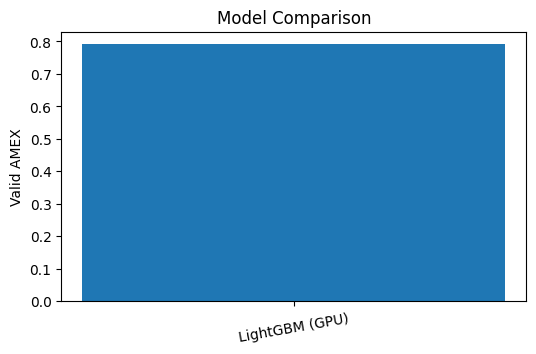

In [27]:
import matplotlib.pyplot as plt

labels = [r["Model"] for r in results]
scores = [r["Valid AMEX"] for r in results]

plt.figure(figsize=(6,3.5))
plt.bar(labels, scores)
plt.ylabel("Valid AMEX")
plt.title("Model Comparison")
plt.xticks(rotation=10)
plt.show()

## Conclusion 

**Submission choice:** We use **LightGBM (GPU)** for the final predictions as it achieved the best AMEX on validation.  
(Both andom Forest and LightGBM results are kept for reference and ablations.)
